# **Imports & Settings**

In [1]:
from utils_model_dataloader import *
from model_sgmap_munia import *
from utils_model_training import *

import itertools
import json
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
from torch.utils.data import DataLoader
import torch.optim as optim

ModuleNotFoundError: No module named 'diffusers'

In [2]:
# show decimal format (not scientific notation)
pd.options.display.float_format = '{:.4f}'.format

# display all columns
pd.set_option('display.max_columns', None)

# confirm GPU status...
if torch.cuda.is_available():
    print('GPU available...')
else:
    print('GPU NOT available...')

GPU available...


# **Parameters**

In [3]:
########################
# Model Directory Setup
########################

###### unique name for model (used for directory and associated files)
model_name = 'test1'

###### directory for model output
model_dir = f"../models/classification/{model_name}"
if not os.path.isdir(model_dir):
    os.makedirs(model_dir)
else:
    print('Directory already exists!!!\nChange directory or will be Overwritten!!!')

In [12]:
###############
# Model Setup
###############

###### model parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
num_epochs = 15


###### dictionary of modalities for model (informal name with unique identifier filename)
modalities = {
    'plancurv': ['plancurv.tif']
    # 'ep': ['ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif'], 
    }


##### attention (None, self attention (1 modality), or cross attention (>=2  modalities))
# NOTE: must match modalities; query applied to first, and key/value applied to second
attention_configs = None
# attention_configs = {'sa_dem': ['dem']}
# attention_configs = {}
# modality_permutations = list(itertools.permutations(modalities.keys(), 2))
# attn_name_prefix = 'ca_' if len(modality_permutations) > 1 else 'sa_'
# for combo in modality_permutations:
#     attn_name = attn_name_prefix + '_'.join(combo)
#     attention_configs[attn_name] = combo


##### encoder weights (pretrained or random initialization)
# weights_config = None
weights_config = 'IMAGENET1K_V2'


##### encoder class
encoder = ResNextEncoder(weights_config).to(device)


##### initialize full model
model = MultilabelClassification(modality_configs=modalities, encoder=encoder, attention_configs=attention_configs).to(device)


##### optimizer
optimizer = optim.Adam(model.parameters())


##### focal loss
reduction = 'mean'
gamma = 2

# alpha...
alpha = 0.25

# target_path = glob.glob(r'../data/warren/*_labels.csv')[0]                        # path to patch labels
# targets = pd.read_csv(target_path)                                                # read as dataframe
# targets = targets.iloc[:, 1:]                                                     # extract binary targets
# positive_counts = targets.sum(axis=0).to_numpy(dtype=np.float32)                  # get class counts

# alpha = 1 / positive_counts                           # inverse class frequency
# # alpha_norm = alpha_icf / alpha_icf.mean()                 # normalized ICF (mean=1)
# alpha = np.sqrt(alpha)                           # normalized square root ICF (mean=1)
# alpha = alpha / alpha.mean()    
# # beta = 0.999                                              # class-balanced (Cui et al., 2019)
# alpha_cb = (1 - beta) / (1 - beta ** positive_counts)
# alpha_cb = alpha_cb / alpha_cb.mean()


alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)           # convert to tensor

# loss function...
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)   # initialize focal loss


In [13]:
alpha

tensor([[0.2500]], device='cuda:0')

In [14]:
################
# Patches Setup
################

###### paths to patch GeoJSONs
train_patch_path = r'../models/patches/warren_patches_train.geojson'
val_patch_path = r'../models/patches/warren_patches_val.geojson'
test_patch_path = r'../models/patches/warren_patches_test.geojson'
hardin_test_patch_path = r'../models/patches/hardin_patches_test.geojson'


###### directories where patches are stored
patch_dir = r'../data/patches_warren'           # main set
hardin_patch_dir = r'../data/patches_hardin'    # secondary test set


####### normalization parameters
norm_stats_path = r'../data/warren/image_stats.csv'
df = pd.read_csv(norm_stats_path)
norm_params = {}
for modality, channels in modalities.items():
    means = []
    stds = []
    for channel in channels:
        if ('osm' in channel) or ('nhd' in channel):
            norm_params[modality] = None
        # elif modality == 'slope':
        #     stats = df.loc[df['path']==channel]
        #     means.append(np.exp(stats['mean'].item()))
        #     stds.append(np.exp(stats['std'].item()))
        #     norm_params[modality] = [means, stds]
        else:
            stats = df.loc[df['path']==channel]
            means.append(stats['mean'].item())
            stds.append(stats['std'].item())
            norm_params[modality] = [means, stds]


In [15]:
##################
# Metadata Log
##################

##### initialize dictionaries for log
metadata = {}
patches_meta = {}
modalities_meta = {}
hyper_meta = {}
model_meta = {}

##### collect setup info
metadata['NAME'] = model_name
metadata['DIRECTORY'] = model_dir

##### collect patches info
patches_meta['train patches'] = train_patch_path
patches_meta['train patches directory'] = patch_dir
patches_meta['validation patches'] = val_patch_path
patches_meta['validation patches directory'] = patch_dir
patches_meta['in-domain test patches'] = test_patch_path
patches_meta['in-domain test patches directory'] = patch_dir
patches_meta['cross-domain test patches'] = hardin_test_patch_path if not hardin_test_patch_path is None else None
patches_meta['cross-domain test patches directory'] = hardin_patch_dir if not hardin_patch_dir is None else None
metadata['PATCHES'] = patches_meta

##### collect modalitiy info
modalities_meta['modalities'] = modalities
modalities_meta['normalization values'] = norm_params
metadata['MODALITIES'] = modalities_meta

##### collect hyperparameters info
hyper_meta['batch size'] = batch_size
hyper_meta['epochs'] = num_epochs
hyper_meta['optimizer'] = type(optimizer).__name__
hyper_meta['learning rate'] = optimizer.param_groups[0]['lr']
hyper_meta['weight decay'] = optimizer.param_groups[0].get('weight_decay', None)
hyper_meta['momentum'] = optimizer.param_groups[0].get('momentum', None)
hyper_meta['loss'] = type(criterion).__name__
hyper_meta['alpha'] = criterion.alpha.cpu().numpy().tolist()
hyper_meta['gamma'] = criterion.gamma
metadata['HYPERPARAMETERS'] = hyper_meta

##### collect model info
model_meta['encoder'] = type(encoder).__name__
model_meta['weights'] = weights_config
model_meta['attention'] = attention_configs
model_meta['model'] = type(model).__name__
metadata['MODEL'] = model_meta

##### write log to json
with open(f"{model_dir}/metadata.json", 'w') as f:
    json.dump(metadata, f, indent=4)

# **DataLoaders**

In [16]:
###########################################
# Get IDs for Train, Validation, Test Sets
###########################################

##### get lists of training, validation, and test patch IDs
# training...
gdf_train = gpd.read_file(train_patch_path)
train_ids = gdf_train['patch_id'].to_list()

# validation...
gdf_val = gpd.read_file(val_patch_path)
val_ids = gdf_val['patch_id'].to_list()

# testing (Warren County)...
gdf_test = gpd.read_file(test_patch_path)
test_ids = gdf_test['patch_id'].to_list()

# testing (Hardin County)...
gdf_hardin_test = gpd.read_file(hardin_test_patch_path)
hardin_test_ids = gdf_hardin_test['patch_id'].to_list()

In [ ]:
# ##############################
# # Oversample Minority Classes
# ##############################

# # get training set labels...
# train_label_path = r'../data/warren/patches_256_50_labels.csv'
# df_labels = pd.read_csv(train_label_path)
# df_labels = df_labels[df_labels['patch_id'].isin(train_ids)]

# # get lists of Qat and Qat patches in training set...
# Qaf_patches = df_labels.loc[df_labels['Qaf'] > 0, 'patch_id'].to_list()
# Qat_patches = df_labels.loc[df_labels['Qat'] > 0, 'patch_id'].to_list()

# # get median class counts
# class_counts = df_labels.iloc[:, 1:].sum(axis=0).to_numpy()
# class_counts_median = np.median(class_counts)

# # calculate number of new patches needed for oversampling to median...
# additional_Qaf = int(class_counts_median - len(Qaf_patches))
# additional_Qat = int(class_counts_median - len(Qat_patches))

# # get list of patch IDs for oversampling...
# new_Qaf_patches = list(np.random.choice(Qaf_patches, size=additional_Qaf, replace=True))
# new_Qat_patches = list(np.random.choice(Qat_patches, size=additional_Qat, replace=True))

# # append additional oversample list to existing training list...
# train_ids.extend(new_Qaf_patches)
# train_ids.extend(new_Qat_patches)


# ##### plot oversampled data distribution (optional)
# df_oversampled = pd.DataFrame({'patch_id': train_ids})
# df_oversampled = pd.merge(left=df_oversampled, right=df_labels, how='left', on='patch_id')
# df_oversampled = df_oversampled.iloc[:, 1:].sum(axis=0)
# df_oversampled = pd.DataFrame(df_oversampled)

# fig, ax = plt.subplots(figsize=(4,4))

# sns.barplot(ax=ax, x=df_oversampled.index, y=df_oversampled[0], edgecolor='k', linewidth=0.5)
# ax.set_xlabel('')
# ax.set_ylabel('Frequency')
# ax.set_title('Oversampled Class Distribution', style='italic')

# plt.show()   

In [17]:
########################################
# Setup Custom Datasets and DataLoaders 
########################################

##### create custom datasets
train_dataset = MultiModalDataset(ids=train_ids, 
                                  data_dir=patch_dir, 
                                  modalities=modalities, 
                                  norm_params=norm_params, 
                                  augment=True, 
                                  task='classification')

val_dataset = MultiModalDataset(ids=val_ids, 
                                data_dir=patch_dir, 
                                modalities=modalities, 
                                norm_params=norm_params, 
                                augment=False, 
                                task='classification')

test_dataset = MultiModalDataset(ids=test_ids, 
                                 data_dir=patch_dir, 
                                 modalities=modalities, 
                                 norm_params=norm_params, 
                                 augment=False, 
                                 task='classification')

hardin_test_dataset = MultiModalDataset(ids=hardin_test_ids, 
                                        data_dir=hardin_patch_dir, 
                                        modalities=modalities, 
                                        norm_params=norm_params, 
                                        augment=False, 
                                        task='classification')

#### create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)
hardin_test_loader = DataLoader(hardin_test_dataset, batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

## *DataLoader Example*

In [ ]:
# ##################
# # Verify Contents
# ##################

# # extract example
# example = next(iter(test_loader))

# ##### print data report
# for modality in example.keys():
#     print(modality)
#     print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")


In [ ]:
# ####################
# # Visualize Example
# ####################

# ##### plot modalities & labels
# ncols = 2
# nrows = 1
# uneven = len(modalities) % ncols
# if len(modalities) > ncols:
#     if not uneven:
#         nrows = len(modalities) / ncols
#     else:
#         nrows = (len(modalities) // ncols) + 1

# fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 5*nrows))
# ax = ax.ravel()

# idx = 0
# for modality in example.keys():
#     if not 'label' in modality:
#         image = prep_image_for_plot(example[modality][0])
#         ax[idx].imshow(image)
#         ax[idx].set_title(modality, style='italic')
#         idx += 1
#     else:
#         label_vec = example['label'][0].numpy().ravel()

# if uneven:
#     fig.delaxes(ax[-1])

# plt.suptitle(f"Labels: [af1, Qal, Qaf, Qat, Qc, Qca, Qr]\nEncoded Labels: {label_vec}", y=1)
# plt.tight_layout()
# plt.show()

# **Model**

## *Training*

In [ ]:
########################
# Training & Validation
#######################


##### train
train_loss, train_acc, val_loss, val_acc, best_model = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, model_dir)


##### append training data to log...
# collect data
training_data = {}
training_data['training loss'] = train_loss
training_data['training accuracy'] = train_acc
training_data['validation loss'] = val_loss
training_data['validation accuracy'] = val_acc

# append to metadata log
metadata['TRAINING'] = training_data

# write updated metadata log to file
with open(f"{model_dir}/metadata.json", 'w') as f:
    json.dump(metadata, f, indent=4)


In [ ]:
#############################
# Visualize Training Results
#############################

fig, ax = plt.subplots(ncols=2, figsize=(10,6))

epochs = range(1, len(train_loss)+1)

ax[0].plot(epochs, train_loss, label='Train')
ax[0].plot(epochs, val_loss, label='Validation')
ax[0].set_title('Focal Loss', style='italic')

ax[1].plot(epochs, train_acc, label='Train')
ax[1].plot(epochs, val_acc, label='Validation')
ax[1].set_title('Overall Accuracy', style='italic')

for axes in ax:
    axes.axvline(x=best_model, linestyle='--', color='k', label='Best model')
    axes.legend(frameon=False)
    axes.set_xticks(epochs)
    axes.set_xticklabels([str(x) if x%5==0 else '' for x in epochs])
    axes.set_xlabel('Epochs')

modalities_str = list(modalities.keys())[0]
if len(modalities.keys()) > 1:
    for modality in list(modalities.keys())[1:]:
        modalities_str = modalities_str + ' + ' + str(modality)

plt.suptitle(f"Multilabel Classification\n{model_name} - {modalities_str}", y=0.99)
plt.savefig(f"{model_dir}/training_results.jpg")
plt.show()


## *Tuning*

In [12]:
##################
# Load Best Model
##################

# load state dictionary of best model
# state_dict = torch.load(f"{model_dir}/best_loss.pth", map_location=device, weights_only=False)
model_dir = r'/Users/matthew/Library/CloudStorage/OneDrive-UniversityofKentucky/earthscape/FocalLoss/fl_dem_11B'
state_dict = torch.load(f"{model_dir}/best_loss.pth", map_location=device, weights_only=False)

# load model with best weights
model.load_state_dict(state_dict)

<All keys matched successfully>

In [13]:
###########################################
# Calculate Optimal Thresholds for Max. F1
###########################################

# calculate optimal thresholds from validation set
optimal_thresholds = calculate_optimal_thresholds(model, val_loader, device)

# array for calculating 0.5 threshold metrics...
optimal_thresholds_05 = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

## *Inference*

### Warren County Test Set

In [14]:
############################
# Make Test Set Predictions
############################

# get predictions and targets from warren test set
# all_predictions, all_targets = test_model(model, test_loader, device)
all_predictions, all_targets = test_model(model, val_loader, device)

In [15]:
################################
# Per Label Performance Metrics
################################

df = pd.DataFrame(columns=['Class', 'Targets', 'Predictions', 'Accuracy', 'Precision', 'Recall', 'F1', 'AP', 'AUROC'])

for idx, (unit, thresh) in enumerate(zip(['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'], optimal_thresholds)):
    df.loc[idx, 'Class'] = unit + f" ({str(round(thresh, 2))})"
    preds = all_predictions[:, idx]
    targs = all_targets[:, idx]
    acc, precision, recall, f1, auc_roc = calculate_label_precision_recall_f1_aucroc(preds, targs, threshold=thresh)
    ap = average_precision_score(targs, preds)
    df.loc[idx, 'Targets'] = int(targs.sum())
    df.loc[idx, 'Predictions'] = (preds >= thresh).sum()
    df.loc[idx, 'Accuracy'] = acc
    df.loc[idx, 'Precision'] = precision
    df.loc[idx, 'Recall'] = recall
    df.loc[idx, 'F1'] = f1
    df.loc[idx, 'AP'] = ap
    df.loc[idx, 'AUROC'] = auc_roc
# df.to_csv(f"{model_dir}/label_metrics_tuned.csv", index=False)
df.T.to_csv(f"{model_dir}/fl_val_tuned.csv")

df.T.head(10)

,0,1,2,3,4,5,6
Class,af1 (0.47),Qal (0.44),Qaf (0.26),Qat (0.34),Qc (0.6),Qca (0.47),Qr (0.55)
Targets,267,501,11,35,379,214,711
Predictions,256,507,31,67,374,239,725
Accuracy,0.8060,0.7917,0.9609,0.9219,0.9102,0.8607,0.9453
Precision,0.7305,0.8363,0.1935,0.3134,0.9144,0.7238,0.9614
Recall,0.7004,0.8463,0.5455,0.6000,0.9024,0.8084,0.9803
F1,0.7151,0.8413,0.2857,0.4118,0.9084,0.7638,0.9708
AP,0.7988,0.9247,0.1475,0.2709,0.9742,0.8441,0.9954
AUROC,0.8442,0.8540,0.9401,0.9056,0.9708,0.9203,0.9471


In [16]:
df = pd.DataFrame(columns=['Class', 'Targets', 'Predictions', 'Accuracy', 'Precision', 'Recall', 'F1', 'AP', 'AUROC'])

for idx, (unit, thresh) in enumerate(zip(['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'], optimal_thresholds_05)):
    df.loc[idx, 'Class'] = unit + f" ({str(round(thresh, 2))})"
    preds = all_predictions[:, idx]
    targs = all_targets[:, idx]
    acc, precision, recall, f1, auc_roc = calculate_label_precision_recall_f1_aucroc(preds, targs, threshold=thresh)
    ap = average_precision_score(targs, preds)
    df.loc[idx, 'Targets'] = int(targs.sum())
    df.loc[idx, 'Predictions'] = (preds >= thresh).sum()
    df.loc[idx, 'Accuracy'] = acc
    df.loc[idx, 'Precision'] = precision
    df.loc[idx, 'Recall'] = recall
    df.loc[idx, 'F1'] = f1
    df.loc[idx, 'AP'] = ap
    df.loc[idx, 'AUROC'] = auc_roc
df.T.to_csv(f"{model_dir}/fl_val_05.csv")

df.T.head(10)

,0,1,2,3,4,5,6
Class,af1 (0.5),Qal (0.5),Qaf (0.5),Qat (0.5),Qc (0.5),Qca (0.5),Qr (0.5)
Targets,267,501,11,35,379,214,711
Predictions,221,429,0,1,417,217,745
Accuracy,0.8099,0.7656,0.9857,0.9531,0.8984,0.8607,0.9401
Precision,0.7738,0.8741,0.0000,0.0000,0.8609,0.7465,0.9463
Recall,0.6404,0.7485,0.0000,0.0000,0.9472,0.7570,0.9916
F1,0.7008,0.8065,0.0000,0.0000,0.9020,0.7517,0.9684
AP,0.7988,0.9247,0.1475,0.2709,0.9742,0.8441,0.9954
AUROC,0.8442,0.8540,0.9401,0.9056,0.9708,0.9203,0.9471


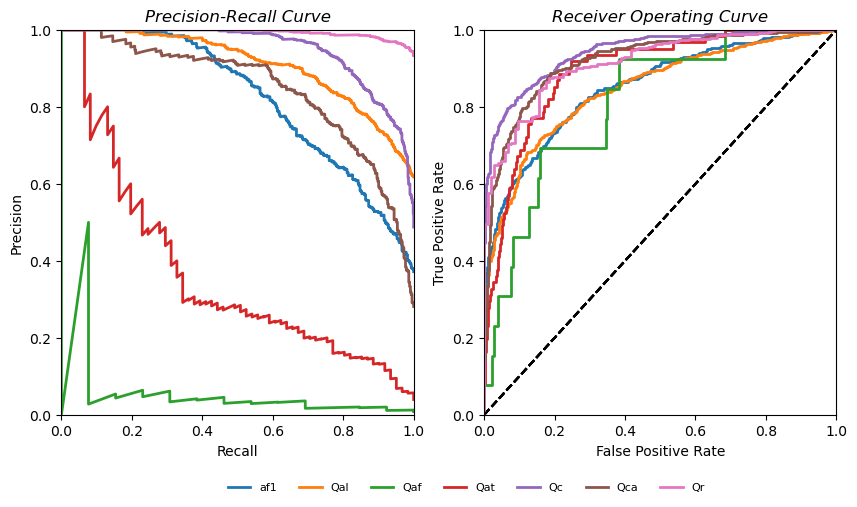

In [16]:
################################
# Precision-Recall & ROC Curves
################################

class_cols = ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr']
fig = plot_label_pr_roc_curves(all_targets, all_predictions, class_cols)
fig.savefig(f"{model_dir}/pr_roc_curves.jpg")


In [50]:
#############################
# Global Performance Metrics
#############################

macro_precision, weighted_precision, macro_recall, weighted_recall, macro_f1, weighted_f1, macro_mAP, weighted_mAP, h_loss, subset_acc, overall_acc = calculate_global_metrics(all_targets, all_predictions, thresholds=optimal_thresholds)

df = pd.DataFrame({'Overall Accuracy': overall_acc, 
                   'Macro Precision': macro_precision, 
                    'Macro Recall': macro_recall, 
                    'Macro F1': macro_f1, 
                    'Weighted Precision': weighted_precision, 
                    'Weighted Recall': weighted_recall,
                    'Weighted F1': weighted_f1, 
                    'Macro mAP': macro_mAP, 
                    'Weighted mAP': weighted_mAP, 
                    'Hamming Loss': h_loss, 
                    'Subset Accuracy':subset_acc}, index=[0])

# df.to_csv(f"{model_dir}/global_metrics_tuned.csv", index=False)
df.to_csv(f"{model_dir}/global_metrics_05.csv", index=False)
df.head()

,Overall Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro mAP,Weighted mAP,Hamming Loss,Subset Accuracy
0,0.8810,0.6466,0.5868,0.6051,0.8541,0.8272,0.8373,0.5571,0.7975,0.1190,0.3691


### Hardin County Test Set

In [51]:
############################
# Make Test Set Predictions
############################

# get predictions and targets from hardin test set
all_predictions, all_targets = test_model(model, hardin_test_loader, device)

In [52]:
################################
# Per Label Performance Metrics
################################

df = pd.DataFrame(columns=['Class', 'Targets', 'Predictions', 'Accuracy', 'Precision', 'Recall', 'F1', 'AP', 'AUROC'])

for idx, (unit, thresh) in enumerate(zip(['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'], optimal_thresholds)):
    df.loc[idx, 'Class'] = unit + f" ({str(round(thresh, 2))})"
    preds = all_predictions[:, idx]
    targs = all_targets[:, idx]
    acc, precision, recall, f1, auc_roc = calculate_label_precision_recall_f1_aucroc(preds, targs, threshold=thresh)
    ap = average_precision_score(targs, preds)
    df.loc[idx, 'Targets'] = int(targs.sum())
    df.loc[idx, 'Predictions'] = (preds >= thresh).sum()
    df.loc[idx, 'Accuracy'] = acc
    df.loc[idx, 'Precision'] = precision
    df.loc[idx, 'Recall'] = recall
    df.loc[idx, 'F1'] = f1
    df.loc[idx, 'AP'] = ap
    df.loc[idx, 'AUROC'] = auc_roc
# df.to_csv(f"{model_dir}/label_metrics_tuned_hardin.csv", index=False)
df.to_csv(f"{model_dir}/label_metrics_05_hardin.csv", index=False)
df.head(10)

,Class,Targets,Predictions,Accuracy,Precision,Recall,F1,AP,AUROC
0,af1 (0.5),435,394,0.7663,0.5964,0.5402,0.5669,0.6254,0.7228
1,Qal (0.5),845,1516,0.5540,0.5528,0.9917,0.7099,0.6891,0.6539
2,Qaf (0.5),6,0,0.9961,0.0000,0.0000,0.0000,0.0085,0.6301
3,Qat (0.5),77,0,0.9499,0.0000,0.0000,0.0000,0.0774,0.6462
4,Qc (0.5),456,374,0.8307,0.7620,0.6250,0.6867,0.7910,0.8820
5,Qca (0.5),249,27,0.8372,0.4815,0.0522,0.0942,0.2621,0.5280
6,Qr (0.5),1511,1536,0.9837,0.9837,1.0000,0.9918,0.9942,0.7854


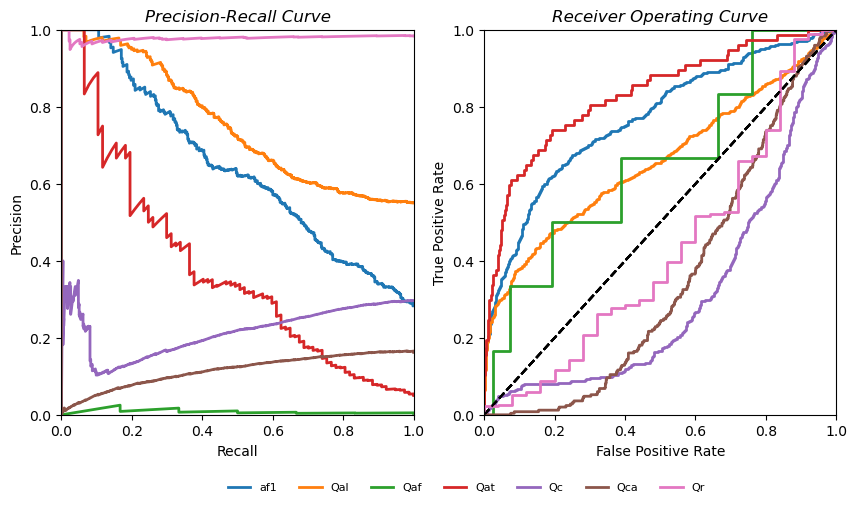

In [20]:
################################
# Precision-Recall & ROC Curves
################################

class_cols = ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr']
fig = plot_label_pr_roc_curves(all_targets, all_predictions, class_cols)
fig.savefig(f"{model_dir}/pr_roc_curves_hardin.jpg")


In [53]:
#############################
# Global Performance Metrics
#############################

macro_precision, weighted_precision, macro_recall, weighted_recall, macro_f1, weighted_f1, macro_mAP, weighted_mAP, h_loss, subset_acc, overall_acc = calculate_global_metrics(all_targets, all_predictions, thresholds=optimal_thresholds)

df = pd.DataFrame({'Overall Accuracy': overall_acc, 
                   'Macro Precision': macro_precision, 
                    'Macro Recall': macro_recall, 
                    'Macro F1': macro_f1, 
                    'Weighted Precision': weighted_precision, 
                    'Weighted Recall': weighted_recall,
                    'Weighted F1': weighted_f1, 
                    'Macro mAP': macro_mAP, 
                    'Weighted mAP': weighted_mAP, 
                    'Hamming Loss': h_loss, 
                    'Subset Accuracy':subset_acc}, index=[0])

# df.to_csv(f"{model_dir}/global_metrics_tuned_hardin.csv", index=False)
df.to_csv(f"{model_dir}/global_metrics_05_hardin.csv", index=False)
df.head()

,Overall Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro mAP,Weighted mAP,Hamming Loss,Subset Accuracy
0,0.8454,0.4824,0.4585,0.4357,0.7489,0.8053,0.7493,0.4013,0.6892,0.1546,0.2546
